# Árbol de Decisión para Regresión

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import sys
sys.path.append('..')
from scripts.database import cargar_datos

# Configuración para mostrar gráficas en Jupyter
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Crear directorio para gráficas
os.makedirs("../data/graficas", exist_ok=True)
print("✅ Librerías importadas")
print("✅ Las gráficas se mostrarán en el notebook")

✅ Librerías importadas
✅ Las gráficas se mostrarán en el notebook


In [6]:
df = cargar_datos()
print(f"📊 Datos: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nPrimeras 5 filas:")
df.head()

📊 Datos: 168 filas, 16 columnas

Primeras 5 filas:


,id,pais_codigo,pais_nombre,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib,region,es_colombia,fecha_extraccion,crecimiento_pib_pc_pct,balanza_comercial_pct
0,1,AR,Argentina,2000,2.842038e+11,-0.7890,7637.0149,NaN,15.000,10.9864,11.6361,América Latina,False,2026-03-05 21:35:13.377882,None,None
1,2,AR,Argentina,2001,2.686968e+11,-4.4088,7141.4751,NaN,17.320,11.5790,10.2732,América Latina,False,2026-03-05 21:35:13.377882,None,None
2,3,AR,Argentina,2002,9.772400e+10,-10.8945,2569.6996,NaN,19.590,28.3826,13.3701,América Latina,False,2026-03-05 21:35:13.377882,None,None
3,4,AR,Argentina,2003,1.275870e+11,8.8370,3320.4778,NaN,15.360,25.9309,14.7138,América Latina,False,2026-03-05 21:35:13.377882,None,None
4,5,AR,Argentina,2004,1.646579e+11,9.0296,4242.0210,NaN,13.522,23.8476,16.8450,América Latina,False,2026-03-05 21:35:13.377882,None,None


In [7]:
target = 'pib_per_capita_usd'

features = [
    'pib_usd',
    'crecimiento_pib_pct',
    'inflacion_pct',
    'desempleo_pct',
    'exportaciones_pct_pib',
    'importaciones_pct_pib'
]

# Verificar columnas existentes
features_existentes = [f for f in features if f in df.columns and df[f].notna().any()]
print(f"✅ Características a usar: {features_existentes}")
print(f"✅ Target: {target}")

✅ Características a usar: ['pib_usd', 'crecimiento_pib_pct', 'inflacion_pct', 'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib']
✅ Target: pib_per_capita_usd


In [8]:
df_clean = df.copy()

# Eliminar filas sin target
df_clean = df_clean.dropna(subset=[target])
print(f"📏 Filas después limpiar target: {df_clean.shape[0]}")

# Rellenar nulos con mediana
for col in features_existentes:
    if df_clean[col].isnull().any():
        mediana = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(mediana)
        print(f"  🔧 {col}: rellenados con mediana={mediana:.2f}")

# Preparar X e y
X = df_clean[features_existentes].values
y = df_clean[target].values

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

# Mostrar estadísticas del target
print(f"\n📊 Estadísticas del target (PIB per cápita):")
print(f"  Media:   ${y.mean():,.2f}")
print(f"  Mediana: ${np.median(y):,.2f}")
print(f"  Mínimo:  ${y.min():,.2f}")
print(f"  Máximo:  ${y.max():,.2f}")

📏 Filas después limpiar target: 168
  🔧 pib_usd: rellenados con mediana=328004092885.23
  🔧 inflacion_pct: rellenados con mediana=3.77

✅ X shape: (168, 6)
✅ y shape: (168,)

📊 Estadísticas del target (PIB per cápita):
  Media:   $14,695.12
  Mediana: $8,874.80
  Mínimo:  $1,929.57
  Máximo:  $81,032.26


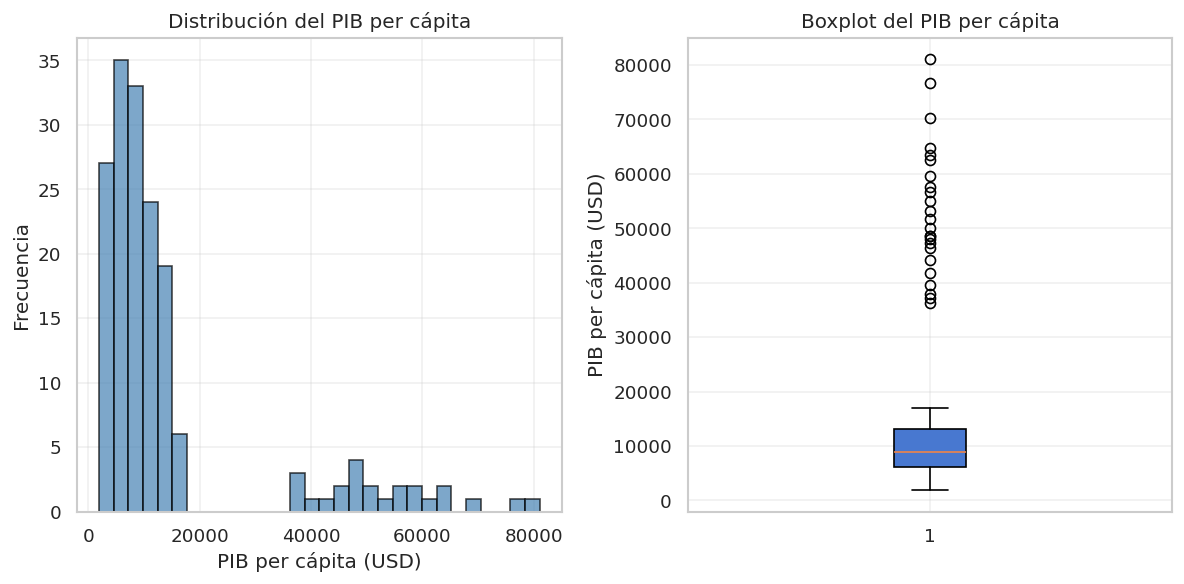

📁 Gráfica también guardada en: ../data/graficas/dt_reg_distribucion_target.png


In [9]:
plt.figure(figsize=(10, 5))

# Histograma
plt.subplot(1, 2, 1)
plt.hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia')
plt.title('Distribución del PIB per cápita')
plt.grid(True, alpha=0.3)

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(y, vert=True, patch_artist=True)
plt.ylabel('PIB per cápita (USD)')
plt.title('Boxplot del PIB per cápita')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/graficas/dt_reg_distribucion_target.png", dpi=120)
plt.show()
print("📁 Gráfica también guardada en: ../data/graficas/dt_reg_distribucion_target.png")

In [11]:
def evaluar_split(X, y, test_size, nombre):
    # División
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Entrenar (CART)
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"📊 {nombre} ({(1-test_size)*100:.0f}/{test_size*100:.0f})")
    print(f"{'='*50}")
    print(f"  R²:   {r2:.4f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE:  ${mae:,.2f}")
    
    # Gráfica 1: Predicción vs Real
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='black')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Valor Real (USD)')
    plt.ylabel('Predicción (USD)')
    plt.title(f'Predicción vs Real\nR² = {r2:.4f}')
    plt.grid(True, alpha=0.3)
    
    # Gráfica 2: Residuos
    residuos = y_test - y_pred
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuos, alpha=0.5, edgecolors='black')
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel('Predicción (USD)')
    plt.ylabel('Residuo (USD)')
    plt.title(f'Residuos vs Predicciones')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"../data/graficas/dt_reg_{nombre}_graficas.png", dpi=120)
    plt.show()
    
    return {'r2': r2, 'rmse': rmse, 'mae': mae}, modelo


📊 80_20 (80/20)
  R²:   0.9730
  RMSE: $2,495.97
  MAE:  $1,671.40


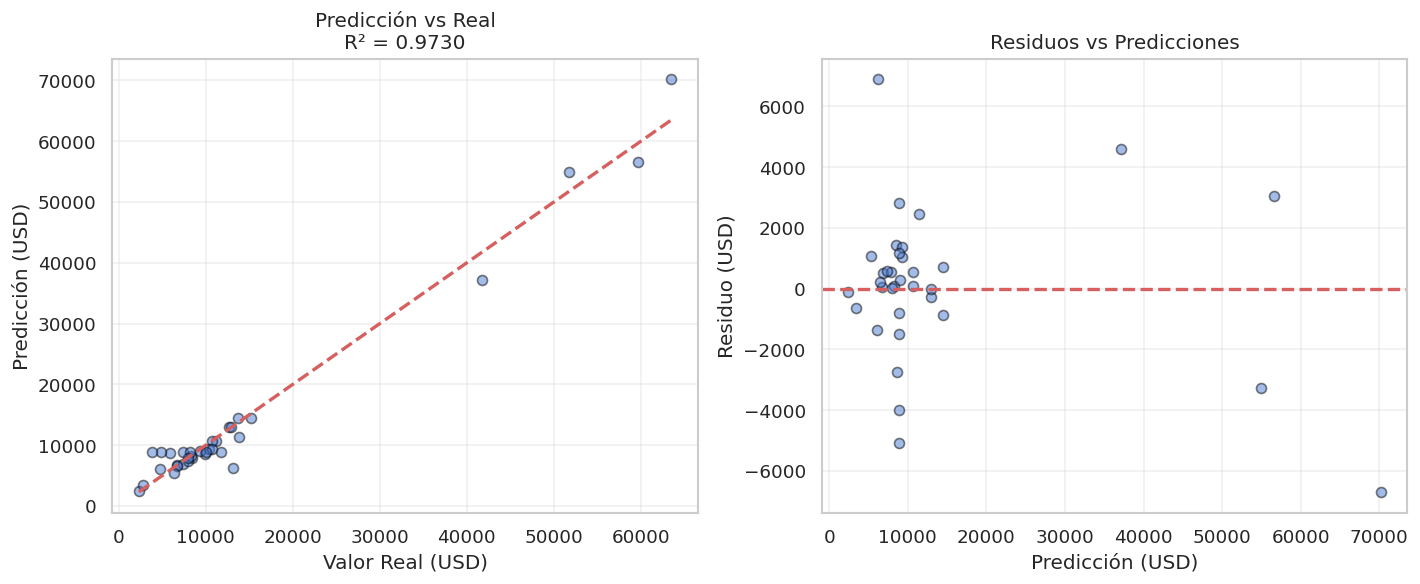

In [12]:
resultados = {}
modelos = {}

res, model = evaluar_split(X, y, test_size=0.20, nombre="80_20")
resultados['80/20'] = res
modelos['80/20'] = model


📊 60_40 (60/40)
  R²:   0.9603
  RMSE: $2,792.57
  MAE:  $1,792.63


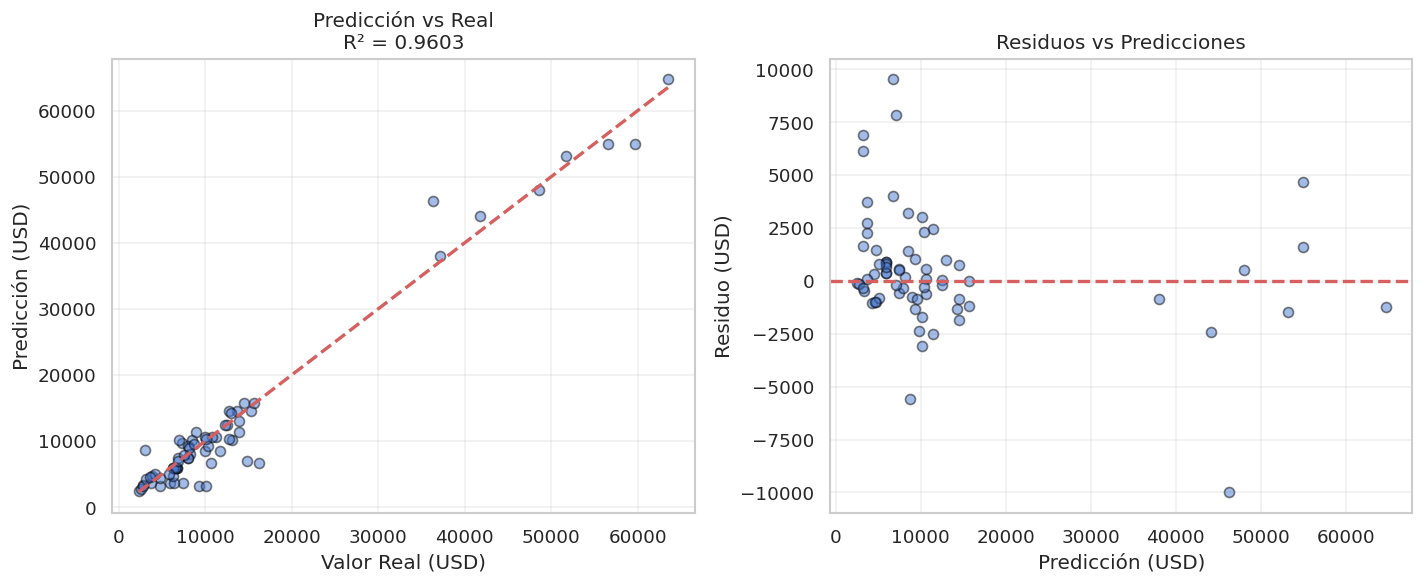

In [13]:
res, model = evaluar_split(X, y, test_size=0.40, nombre="60_40")
resultados['60/40'] = res
modelos['60/40'] = model


📊 70_30 (70/30)
  R²:   0.9544
  RMSE: $3,033.99
  MAE:  $1,888.30


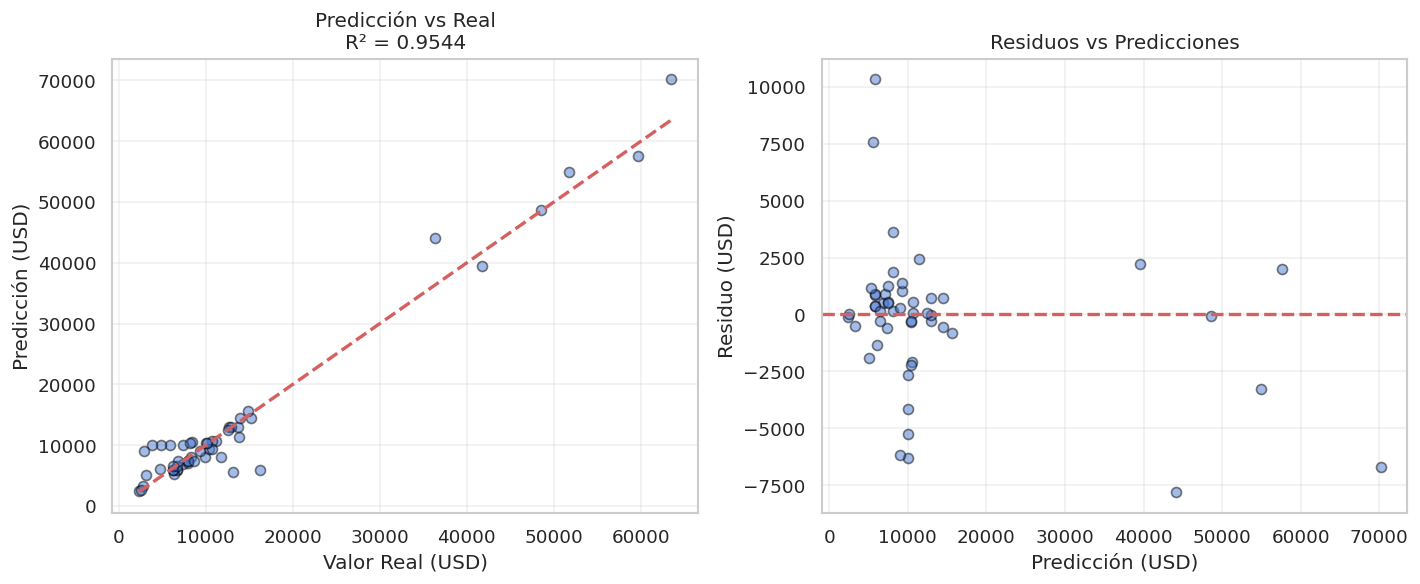

In [14]:
res, model = evaluar_split(X, y, test_size=0.30, nombre="70_30")
resultados['70/30'] = res
modelos['70/30'] = model


📊 TABLA COMPARATIVA DE MÉTRICAS
           r2       rmse        mae
80/20  0.9730  2495.9749  1671.4041
60/40  0.9603  2792.5673  1792.6269
70/30  0.9544  3033.9898  1888.3048

📈 Estabilidad R²: ±0.00954


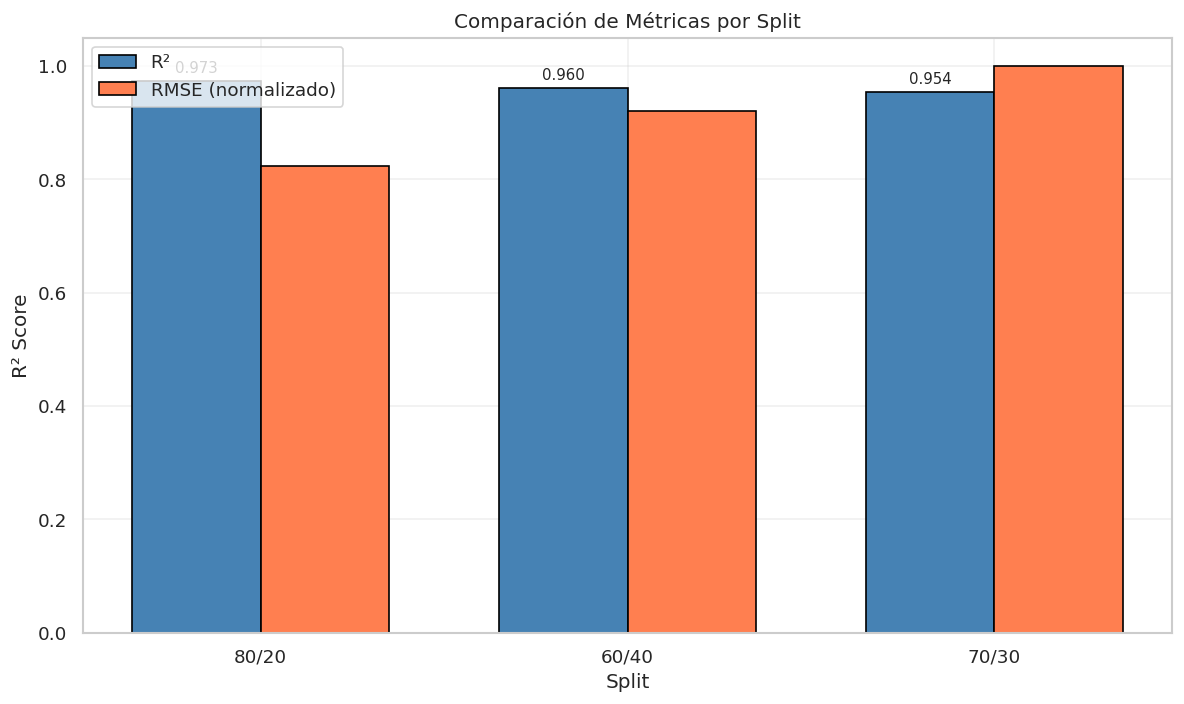

In [15]:
df_res = pd.DataFrame(resultados).T
print("\n📊 TABLA COMPARATIVA DE MÉTRICAS")
print("="*60)
print(df_res.round(4))
print(f"\n📈 Estabilidad R²: ±{df_res['r2'].std():.5f}")

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_res))
width = 0.35

bars1 = ax.bar(x - width/2, df_res['r2'], width, label='R²', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, df_res['rmse'] / df_res['rmse'].max(), width, label='RMSE (normalizado)', color='coral', edgecolor='black')

ax.set_xlabel('Split')
ax.set_ylabel('R² Score')
ax.set_title('Comparación de Métricas por Split')
ax.set_xticks(x)
ax.set_xticklabels(df_res.index)
ax.legend()
ax.grid(True, alpha=0.3)

# Agregar valores en las barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../data/graficas/dt_reg_comparativa.png", dpi=120)
plt.show()

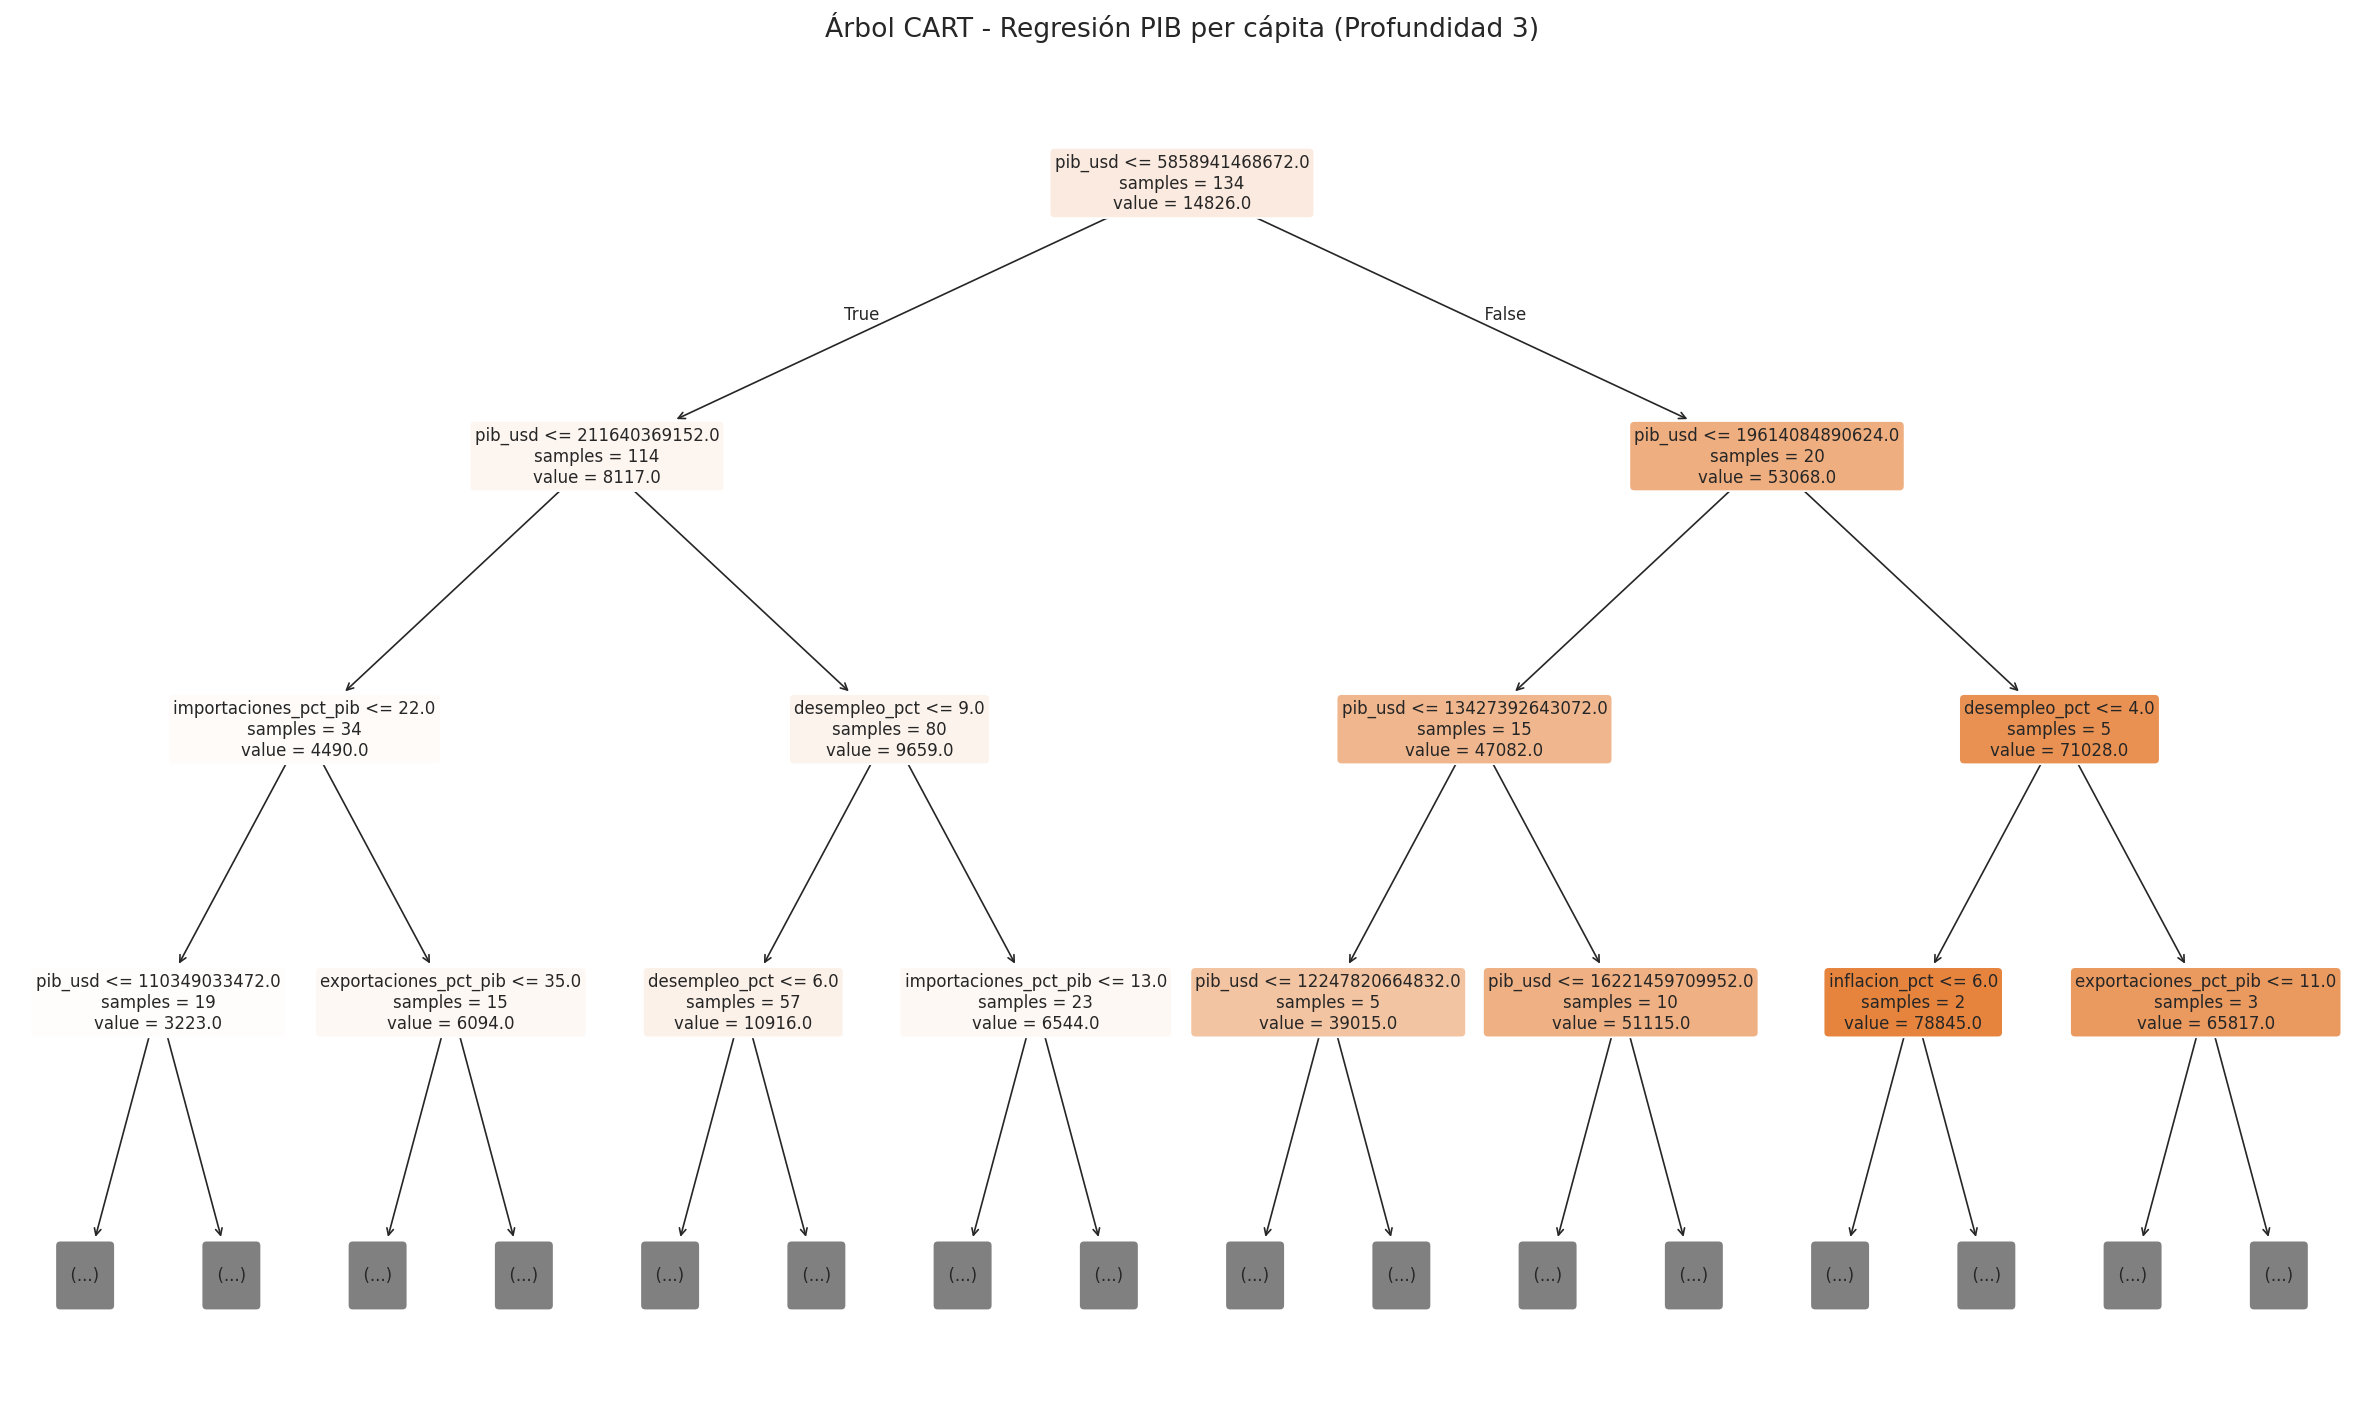

📁 Árbol guardado en: ../data/graficas/dt_reg_arbol.png


In [16]:
modelo_viz = modelos['80/20']

plt.figure(figsize=(20, 12))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=features_existentes,
    filled=True,
    rounded=True,
    impurity=False,
    precision=0,
    fontsize=10
)
plt.title("Árbol CART - Regresión PIB per cápita (Profundidad 3)", fontsize=16)
plt.tight_layout()
plt.savefig("../data/graficas/dt_reg_arbol.png", dpi=150)
plt.show()
print("📁 Árbol guardado en: ../data/graficas/dt_reg_arbol.png")

📊 IMPORTANCIA DE CARACTERÍSTICAS
  pib_usd                             → 0.9709 (97.1%)
  desempleo_pct                       → 0.0168 (1.7%)
  importaciones_pct_pib               → 0.0060 (0.6%)
  exportaciones_pct_pib               → 0.0057 (0.6%)
  inflacion_pct                       → 0.0004 (0.0%)
  crecimiento_pib_pct                 → 0.0002 (0.0%)


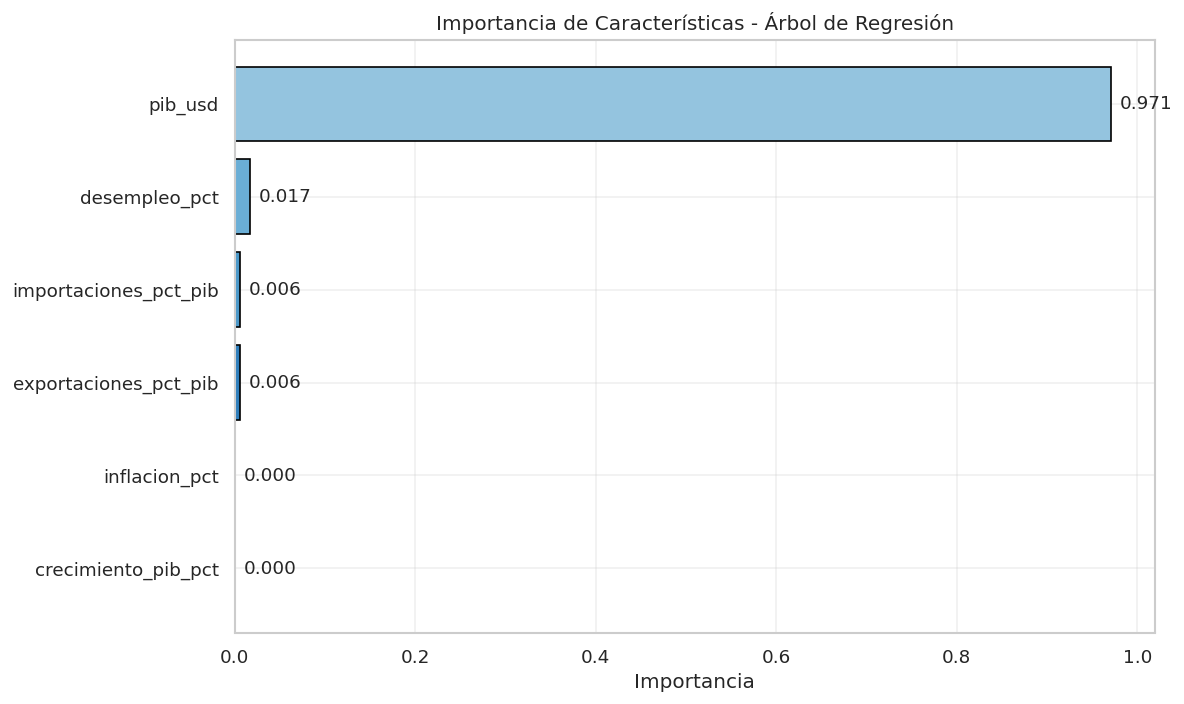

In [17]:
importancia = pd.DataFrame({
    'Característica': features_existentes,
    'Importancia': modelo_viz.feature_importances_
}).sort_values('Importancia', ascending=False)

print("📊 IMPORTANCIA DE CARACTERÍSTICAS")
print("="*50)
for _, row in importancia.iterrows():
    print(f"  {row['Característica']:<35} → {row['Importancia']:.4f} ({row['Importancia']*100:.1f}%)")

# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importancia)))
plt.barh(importancia['Característica'], importancia['Importancia'], color=colors, edgecolor='black')
plt.xlabel('Importancia')
plt.title('Importancia de Características - Árbol de Regresión')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

# Agregar valores
for i, v in enumerate(importancia['Importancia']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig("../data/graficas/dt_reg_importancia.png", dpi=120)
plt.show()

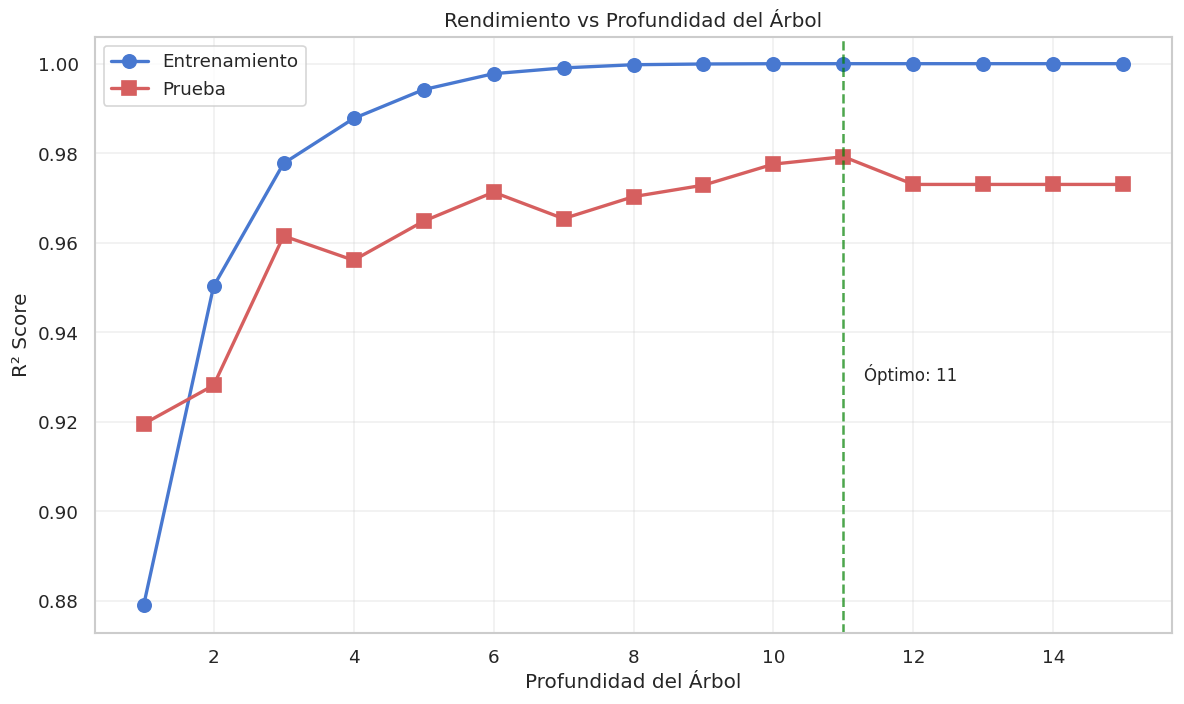

🎯 Mejor profundidad: 11
🎯 Mejor R² en prueba: 0.9792


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

profundidades = range(1, 16)
train_scores = []
test_scores = []

for d in profundidades:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(profundidades, train_scores, 'b-o', linewidth=2, markersize=8, label='Entrenamiento')
plt.plot(profundidades, test_scores, 'r-s', linewidth=2, markersize=8, label='Prueba')
plt.xlabel('Profundidad del Árbol')
plt.ylabel('R² Score')
plt.title('Rendimiento vs Profundidad del Árbol')
plt.legend()
plt.grid(True, alpha=0.3)

# Marcar mejor profundidad
best_idx = np.argmax(test_scores)
best_depth = profundidades[best_idx]
plt.axvline(x=best_depth, color='green', linestyle='--', alpha=0.7)
plt.text(best_depth + 0.3, max(test_scores) - 0.05, f'Óptimo: {best_depth}', fontsize=10)

plt.tight_layout()
plt.savefig("../data/graficas/dt_reg_profundidad.png", dpi=120)
plt.show()

print(f"🎯 Mejor profundidad: {best_depth}")
print(f"🎯 Mejor R² en prueba: {max(test_scores):.4f}")


📊 VALIDACIÓN CRUZADA (5 folds)
  R² promedio: -0.6530
  Desviación:  ±1.1160
  ±2σ:         ±2.2320
  Scores:      [ 0.01873761 -2.53995072  0.17386315  0.39458816 -1.31205083]


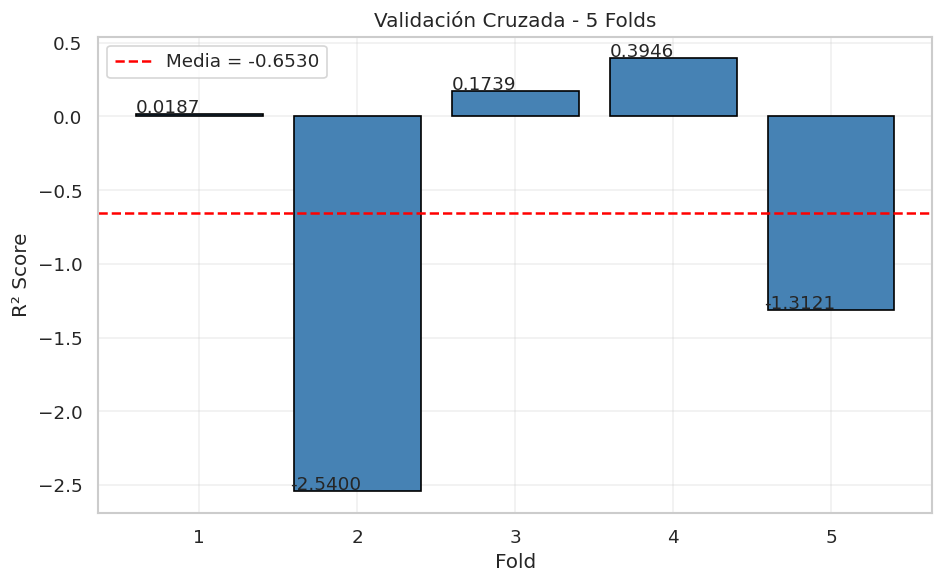

In [19]:
print("\n📊 VALIDACIÓN CRUZADA (5 folds)")
print("="*40)

cv_scores = cross_val_score(modelo_viz, X, y, cv=5, scoring='r2')
print(f"  R² promedio: {cv_scores.mean():.4f}")
print(f"  Desviación:  ±{cv_scores.std():.4f}")
print(f"  ±2σ:         ±{cv_scores.std() * 2:.4f}")
print(f"  Scores:      {cv_scores}")

# Gráfica de CV
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Media = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Validación Cruzada - 5 Folds')
plt.legend()
plt.grid(True, alpha=0.3)

for i, v in enumerate(cv_scores):
    plt.text(i + 0.8, v + 0.01, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig("../data/graficas/dt_reg_crossval.png", dpi=120)
plt.show()

In [20]:
# Tomar un ejemplo aleatorio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
indice = 0

real = y_test[indice]
predicho = modelos['80/20'].predict([X_test[indice]])[0]
error = abs(real - predicho)

print("\n📊 EJEMPLO DE PREDICCIÓN")
print("="*50)
print(f"\nCaracterísticas del país:")
for i, col in enumerate(features_existentes):
    print(f"  {col:<35}: ${X_test[indice][i]:,.2f}")

print(f"\n💰 PIB per cápita REAL:     ${real:,.2f}")
print(f"💰 PIB per cápita PREDICHO: ${predicho:,.2f}")
print(f"📉 Error absoluto:          ${error:,.2f}")
print(f"📊 Error relativo:          {(error/real)*100:.2f}%")


📊 EJEMPLO DE PREDICCIÓN

Características del país:
  pib_usd                            : $211,007,984,080.91
  crecimiento_pib_pct                : $2.52
  inflacion_pct                      : $2.99
  desempleo_pct                      : $3.69
  exportaciones_pct_pib              : $24.72
  importaciones_pct_pib              : $22.79

💰 PIB per cápita REAL:     $6,736.17
💰 PIB per cápita PREDICHO: $6,667.13
📉 Error absoluto:          $69.03
📊 Error relativo:          1.02%


In [28]:
print("\n" + "="*60)
print("📝 CONCLUSIONES - ÁRBOL DE REGRESIÓN (CART)")
print("="*60)

# Valores clave
mejor_r2 = df_res['r2'].max()
mejor_rmse = df_res['rmse'].min()
mejor_mae = df_res['mae'].min()
var_importante = importancia.iloc[0]['Característica']

print(f"""
✅ RENDIMIENTO:
   • R²: {mejor_r2:.4f} ({mejor_r2*100:.1f}%)
   • RMSE: ${mejor_rmse:,.2f}
   • MAE: ${mejor_mae:,.2f}

✅ ANÁLISIS:
   • Variable más importante: {var_importante}
   • Profundidad óptima: {best_depth}
   • Validación cruzada: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

✅ RESTRICCIONES:
   • Sin ensembles ✓
   • CART permitido ✓
   • Sin SMOTE ✓
   • Con resampling ✓

📁 Gráficas guardadas en: ../data/graficas/
""")

print("="*60)
print("✅ NOTEBOOK COMPLETADO")
print("="*60)


📝 CONCLUSIONES - ÁRBOL DE REGRESIÓN (CART)

✅ RENDIMIENTO:
   • R²: 0.9730 (97.3%)
   • RMSE: $2,495.97
   • MAE: $1,671.40

✅ ANÁLISIS:
   • Variable más importante: pib_usd
   • Profundidad óptima: 11
   • Validación cruzada: R² = -0.6530 ± 1.1160

✅ RESTRICCIONES:
   • Sin ensembles ✓
   • CART permitido ✓
   • Sin SMOTE ✓
   • Con resampling ✓

📁 Gráficas guardadas en: ../data/graficas/

✅ NOTEBOOK COMPLETADO
